<a href="https://colab.research.google.com/github/wldanzahrr/Analisis_numerik_gerai_donat/blob/main/25083010002_Muhammad_Wildan_Zahir_ANUM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : MUHAMMAD WILDAN ZAHIR

NPM : 25083010002

Kelas : ANALISIS NUMERIK (A)

link github :https://github.com/wldanzahrr/Analisis_numerik_gerai_donat

Analisis ini bertujuan menentukan titik impas (Breakeven Point/BEP) untuk setiap gerai donat, yaitu jumlah unit penjualan minimum yang harus dicapai agar total pendapatan (revenue) menutupi seluruh biaya operasional — baik biaya tetap (fixed cost) maupun biaya variabel per unit. Di bawah titik ini, gerai mengalami kerugian; di atasnya, gerai mulai menghasilkan keuntungan.

In [ ]:
# 1. Import Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Mengimpor pandas/numpy untuk pengolahan data, matplotlib untuk visualisasi, dan LinearRegression untuk regresi linear.

In [ ]:
# 2. Load Data
# Membaca data dari Github
df = pd.read_csv("sintesis_data_donat_harian.csv")
df.head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


Membaca dataset CSV dan menampilkan 5 baris pertama

In [ ]:
# 3. Ringkasan Data Setiap Gerai
gerai_list = sorted(df["Gerai"].unique())
colors = {"Gerai A": "#1f77b4", "Gerai B": "#ff7f0e", "Gerai C": "#2ca02c",
          "Gerai D": "#d62728", "Gerai E": "#9467bd"}


print("RINGKASAN DATA SETIAP GERAI")

summary = df.groupby("Gerai").agg(
    Harga_Jual=("Harga Jual (Rp)", "first"),
    Fixed_Cost=("Fixed Cost Harian (Rp)", "first"),
    Biaya_Variabel_per_Unit=("Biaya Variabel (Rp)", lambda x: (x / df.loc[x.index, "Jumlah Terjual (Unit)"]).mean()),
    Qty_Min=("Jumlah Terjual (Unit)", "min"),
    Qty_Max=("Jumlah Terjual (Unit)", "max"),
    Qty_Rata2=("Jumlah Terjual (Unit)", "mean"),
)
print(summary.round(1))
print("\nStatistik deskriptif:")
print(df.describe())
print()

RINGKASAN DATA PER GERAI
         Harga_Jual  Fixed_Cost  Biaya_Variabel_per_Unit  Qty_Min  Qty_Max  \
Gerai                                                                        
Gerai A       25000     1683333                   8500.0       81      131   
Gerai B        8000      733333                   4160.0      435      710   
Gerai C       11000     1733333                   4840.0      220      522   
Gerai D       20000     2666666                   7200.0      103      223   
Gerai E       15000      800000                   6300.0      153      332   

         Qty_Rata2  
Gerai               
Gerai A       99.1  
Gerai B      527.5  
Gerai C      328.9  
Gerai D      149.8  
Gerai E      226.6  

Statistik deskriptif:
       Harga Jual (Rp)  Jumlah Terjual (Unit)  Pendapatan Kotor (Rp)  \
count       450.000000             450.000000           4.500000e+02   
mean      15800.000000             266.402222           3.342420e+06   
std        6119.085481             160.911

# 1. PLOT JUMLAH PENJUALAN vs REVENUE

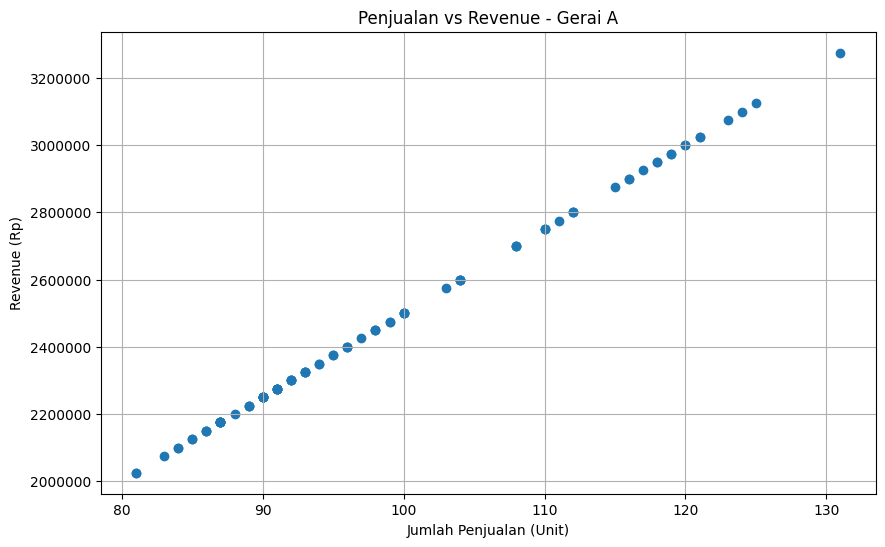

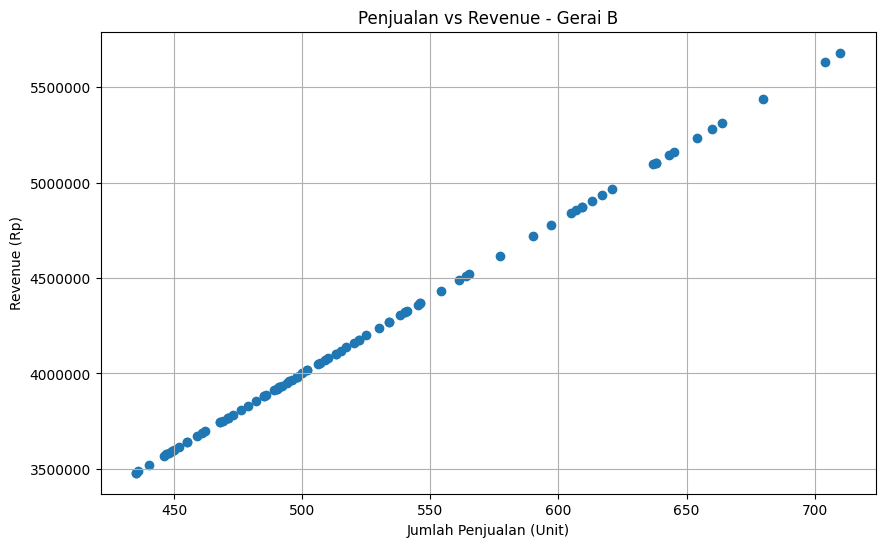

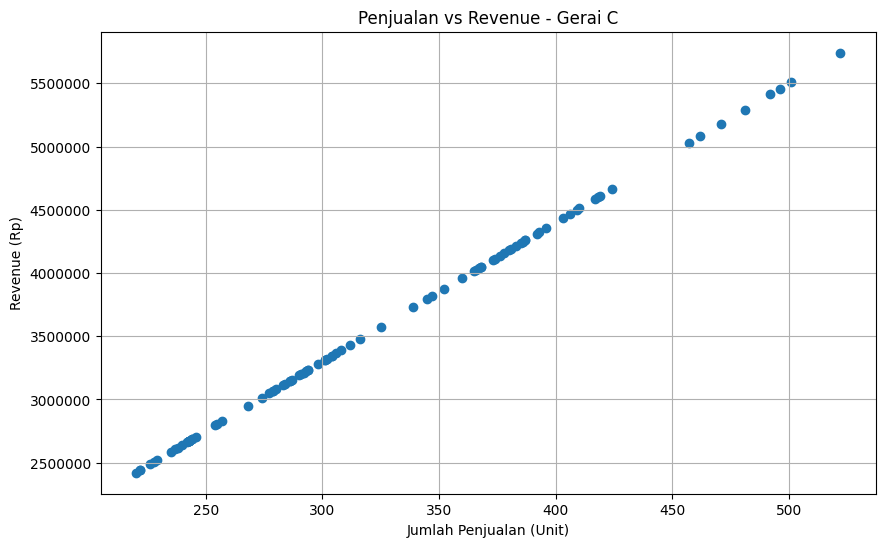

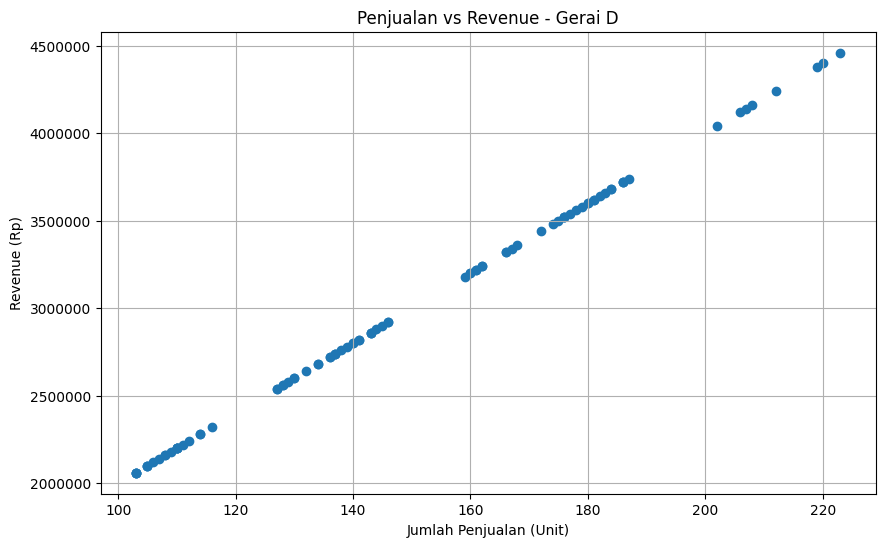

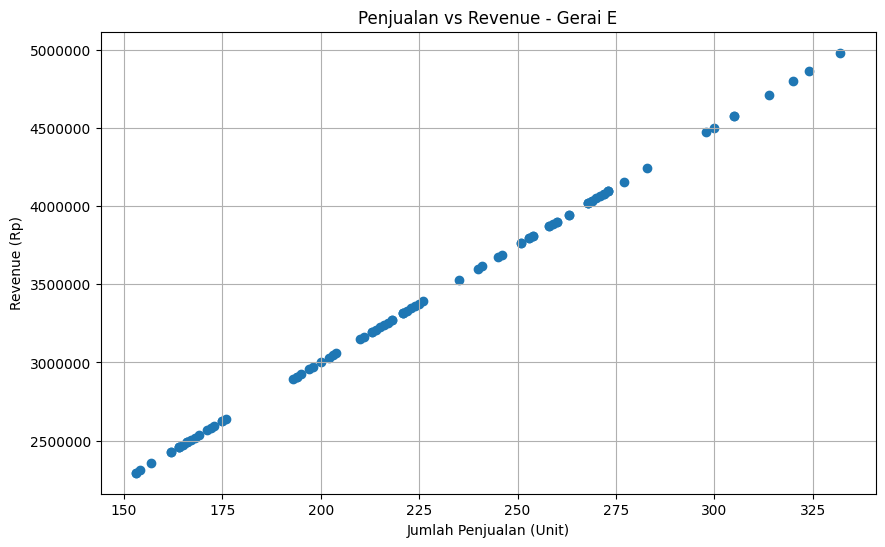

In [ ]:
for gerai in df["Gerai"].unique():
    plt.figure(figsize=(10, 6))
    data = df[df["Gerai"] == gerai]

    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"]
    )

    plt.title("Penjualan vs Revenue - " + gerai)
    plt.xlabel("Jumlah Penjualan (Unit)")
    plt.ylabel("Revenue (Rp)")

    plt.ticklabel_format(style='plain', axis='y')

    plt.grid(True)
    plt.show()

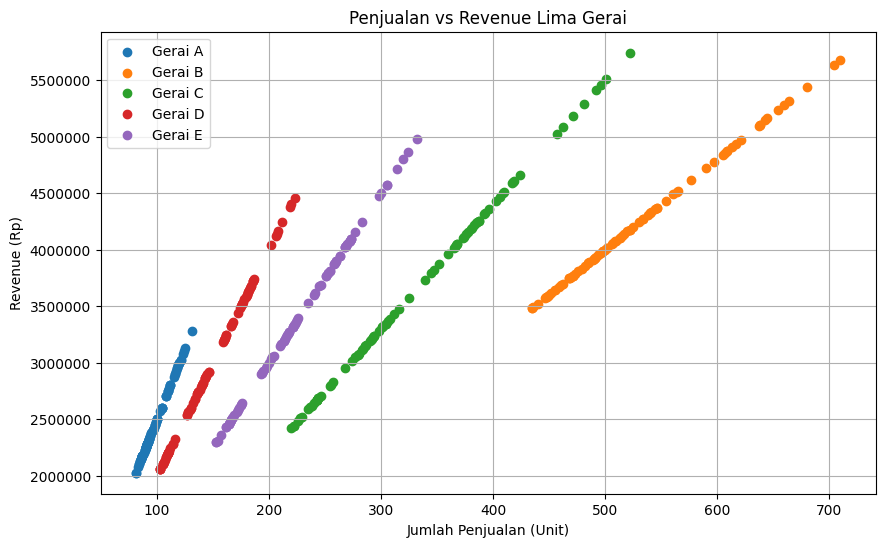

In [ ]:
# subplot ke-6 dipakai untuk overlay semua gerai jadi satu
plt.figure(figsize=(10, 6))

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"],
        label=gerai
    )

plt.title("Penjualan vs Revenue Lima Gerai")
plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")

plt.ticklabel_format(style='plain', axis='y')

plt.legend()
plt.grid(True)
plt.show()


Grafik hubungan antara jumlah penjualan dan revenue menunjukkan tren positif yang konsisten di kelima gerai: semakin banyak donat yang terjual, semakin besar pula revenue yang dihasilkan. Menariknya, pola pada setiap gerai membentuk garis yang mendekati sempurna linear, bukan kurva melengkung seperti polynomial atau eksponensial. Hal ini sejalan dengan sifat data, di mana harga jual per unit pada masing-masing gerai bersifat tetap sepanjang periode pengamatan, sehingga revenue murni merupakan fungsi linear dari volume penjualan, yaitu:

Revenue = Harga Jual × Jumlah Terjual

Selanjutnya, perbedaan yang tampak antar-gerai bukan terletak pada bentuk polanya — karena semuanya linear — melainkan pada kemiringan (slope) garisnya. Gerai dengan harga jual lebih tinggi (misalnya Gerai A dengan harga Rp25.000/unit) memiliki garis yang lebih curam dan menghasilkan revenue lebih besar dibandingkan gerai dengan harga jual lebih rendah (misalnya Gerai B dengan harga Rp8.000/unit), meskipun volume penjualannya sama.

# 2. Regresi Reveneu dari Volume Penjualan

In [ ]:
hasil_regresi = {}

for gerai in df["Gerai"].unique():

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = model.score(X, y)

    hasil_regresi[gerai] = {
        "model": model,
        "slope": slope,
        "intercept": intercept,
        "R2": r2
    }

    print(f"\n{gerai}")
    print(f"Persamaan: Revenue = {slope:.2f} × Penjualan + {intercept:.2f}")
    print(f"R² = {r2:.4f}")


Gerai A
Persamaan: Revenue = 25000.00 × Penjualan + -0.00
R² = 1.0000

Gerai B
Persamaan: Revenue = 8000.00 × Penjualan + 0.00
R² = 1.0000

Gerai C
Persamaan: Revenue = 11000.00 × Penjualan + 0.00
R² = 1.0000

Gerai D
Persamaan: Revenue = 20000.00 × Penjualan + -0.00
R² = 1.0000

Gerai E
Persamaan: Revenue = 15000.00 × Penjualan + -0.00
R² = 1.0000


# Interpretasi Hasil Regresi

persamaan regresi linear revenue terhadap jumlah penjualan untuk kelima gerai, dengan bentuk umum:

Revenue = Harga Jual × Penjualan + Konstanta

Beberapa poin interpretasi:

1. **R² = 1.0000 di seluruh gerai**

Ini menunjukkan model regresi linear menjelaskan 100% variasi data — tidak ada penyimpangan sama sekali antara data aktual dan garis regresi. Ini bukan sekadar "fit yang sangat baik", tapi memang mencerminkan hubungan matematis yang pasti (deterministik), karena revenue memang dihitung langsung dari harga × jumlah unit, bukan hasil estimasi atau proses yang mengandung noise/random.

2. **Koefisien (slope) = harga jual per unit masing-masing gerai**

- Gerai A: 25.000 (harga tertinggi)
- Gerai D: 20.000
- Gerai E: 15.000
- Gerai C: 11.000
- Gerai B: 8.000 (harga terendah)

Slope ini secara langsung menunjukkan seberapa besar revenue bertambah untuk setiap 1 unit donat tambahan yang terjual. Gerai A, misalnya, akan menambah revenue Rp25.000 setiap kali menjual 1 donat tambahan, jauh lebih besar dibanding Gerai B yang hanya menambah Rp8.000 per unit.

VISUALISASI GARIS REGRESI


Gerai A
Gerai: Gerai A
Persamaan regresi: Y = -0.00 + (25,000.00)X
Koefisien regresi (b): 25,000.00
Intercept (a): -0.00
R²: 1.0000
R² (%): 100.00%


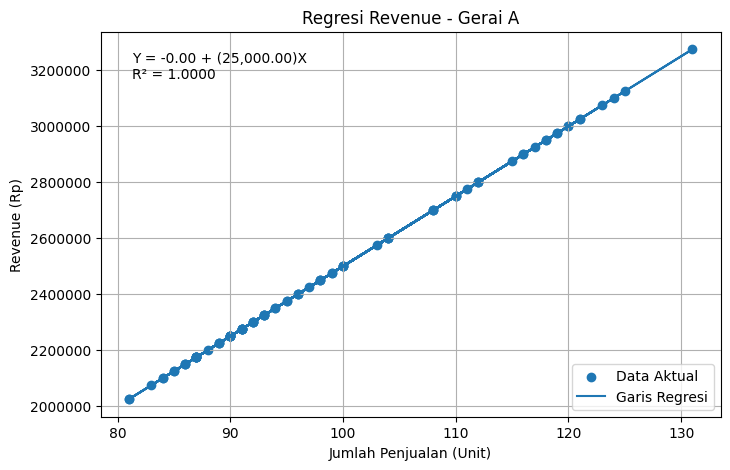


Gerai B
Gerai: Gerai B
Persamaan regresi: Y = 0.00 + (8,000.00)X
Koefisien regresi (b): 8,000.00
Intercept (a): 0.00
R²: 1.0000
R² (%): 100.00%


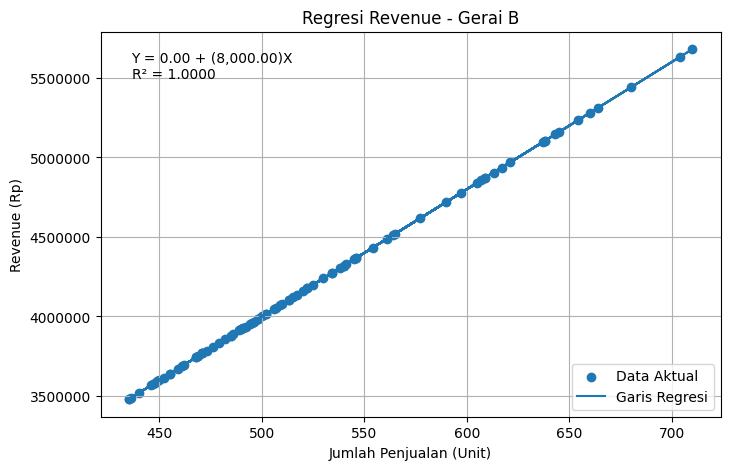


Gerai C
Gerai: Gerai C
Persamaan regresi: Y = 0.00 + (11,000.00)X
Koefisien regresi (b): 11,000.00
Intercept (a): 0.00
R²: 1.0000
R² (%): 100.00%


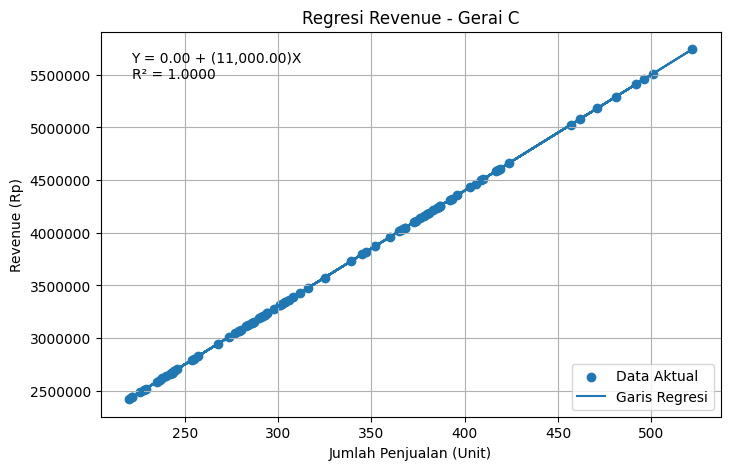


Gerai D
Gerai: Gerai D
Persamaan regresi: Y = -0.00 + (20,000.00)X
Koefisien regresi (b): 20,000.00
Intercept (a): -0.00
R²: 1.0000
R² (%): 100.00%


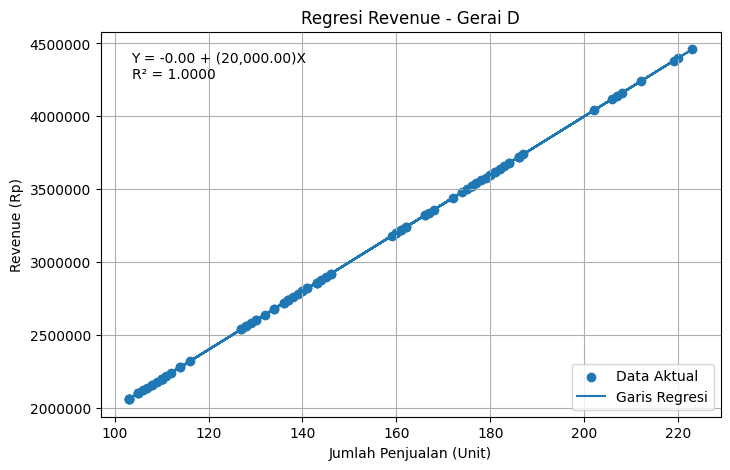


Gerai E
Gerai: Gerai E
Persamaan regresi: Y = -0.00 + (15,000.00)X
Koefisien regresi (b): 15,000.00
Intercept (a): -0.00
R²: 1.0000
R² (%): 100.00%


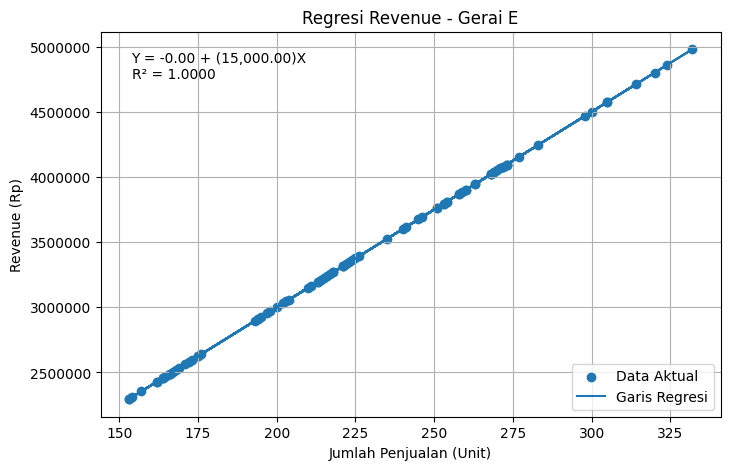

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    # Membuat model regresi
    model = LinearRegression()
    model.fit(X, y)

    # Mengambil nilai koefisien, intercept, dan R²
    b = model.coef_[0]
    a = model.intercept_
    r2 = model.score(X, y)

    # Prediksi
    y_pred = model.predict(X)

    # Menampilkan hasil

    print(f"\n{gerai}")
    print(f"Gerai: {gerai}")
    print(f"Persamaan regresi: Y = {a:,.2f} + ({b:,.2f})X")
    print(f"Koefisien regresi (b): {b:,.2f}")
    print(f"Intercept (a): {a:,.2f}")
    print(f"R²: {r2:.4f}")
    print(f"R² (%): {r2 * 100:.2f}%")

    # Membuat grafik
    plt.figure(figsize=(8, 5))

    plt.scatter(X, y, label="Data Aktual")
    plt.plot(X, y_pred, label="Garis Regresi")

    plt.title("Regresi Revenue - " + gerai)
    plt.xlabel("Jumlah Penjualan (Unit)")
    plt.ylabel("Revenue (Rp)")

    plt.ticklabel_format(style='plain', axis='y')

    # Menampilkan persamaan dan R² di grafik
    plt.text(
        0.05, 0.95,
        f"Y = {a:,.2f} + ({b:,.2f})X\nR² = {r2:.4f}",
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )

    plt.grid(True)
    plt.legend()
    plt.show()

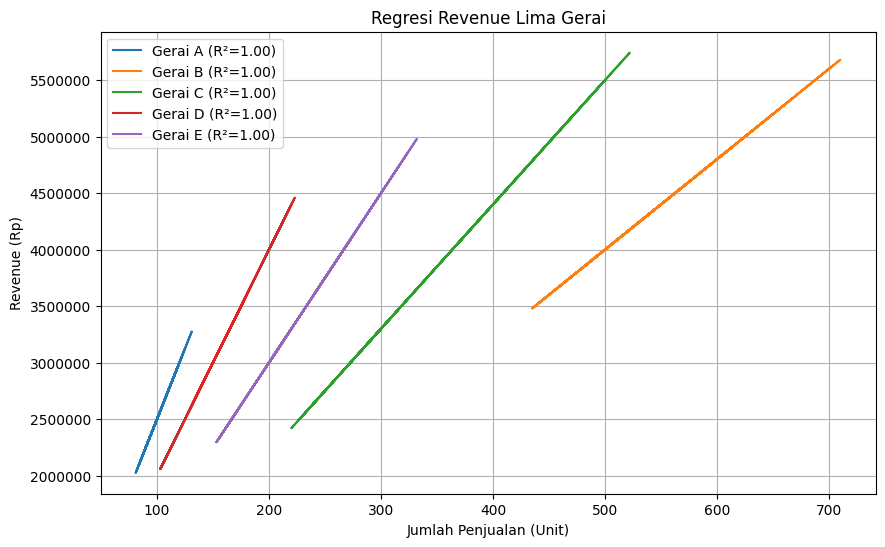

In [ ]:
plt.figure(figsize=(10, 6))

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]
    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression().fit(X, y)

    plt.plot(X, model.predict(X),
             label=f"{gerai} (R²={model.score(X,y):.2f})")

plt.title("Regresi Revenue Lima Gerai")
plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.grid()
plt.show()

# Interpretasi

Grafik tersebut menunjukkan hubungan antara jumlah penjualan (unit) dan pendapatan kotor (revenue) pada lima gerai. Garis regresi menunjukkan kecenderungan perubahan pendapatan berdasarkan jumlah produk yang terjual. Nilai R² menunjukkan seberapa kuat jumlah penjualan dapat menjelaskan perubahan pendapatan pada masing-masing gerai. Semakin mendekati 1, semakin kuat hubungan linear antara kedua variabel tersebut.

# Volume Penjualan untuk menghasilkan Break Even Point pada masing - masing Regresi

In [ ]:
hasil_bep = {}

for gerai in df["Gerai"].unique():

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Balance (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_

    # Mencari akar persamaan balance = 0
    bep = -b / a

    r2 = model.score(X, y)

    hasil_bep[gerai] = {
        "slope": a,
        "intercept": b,
        "BEP": bep,
        "R2": r2
    }

    print(f"\n{gerai}")
    print(f"Persamaan Balance = {a:.2f} × Penjualan + {b:.2f}")
    print(f"BEP = {bep:.2f} unit")
    print(f"R² = {r2:.4f}")


Gerai A
Persamaan Balance = 16500.00 × Penjualan + -1683333.00
BEP = 102.02 unit
R² = 1.0000

Gerai B
Persamaan Balance = 3840.00 × Penjualan + -733333.00
BEP = 190.97 unit
R² = 1.0000

Gerai C
Persamaan Balance = 6160.00 × Penjualan + -1733333.00
BEP = 281.39 unit
R² = 1.0000

Gerai D
Persamaan Balance = 12800.00 × Penjualan + -2666666.00
BEP = 208.33 unit
R² = 1.0000

Gerai E
Persamaan Balance = 8700.00 × Penjualan + -800000.00
BEP = 91.95 unit
R² = 1.0000


# Interpretasi singkat

Program membuat regresi linear antara jumlah terjual dan Balance (Rp). Nilai BEP diperoleh saat Balance = 0, sehingga menunjukkan jumlah unit yang harus terjual agar gerai mencapai titik impas. Sementara itu, R² menunjukkan seberapa kuat jumlah penjualan menjelaskan perubahan Balance.

jika hasil Bep = 208 unit, maka gerai tersebut perlu menjual sekitar 208 unit untuk mencapai titik impas. Di bawah jumlah tersebut, balance diperkirakan negatif, sedangkan di atasnya diperkirakan positif.

# VISUALISASI BEP

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


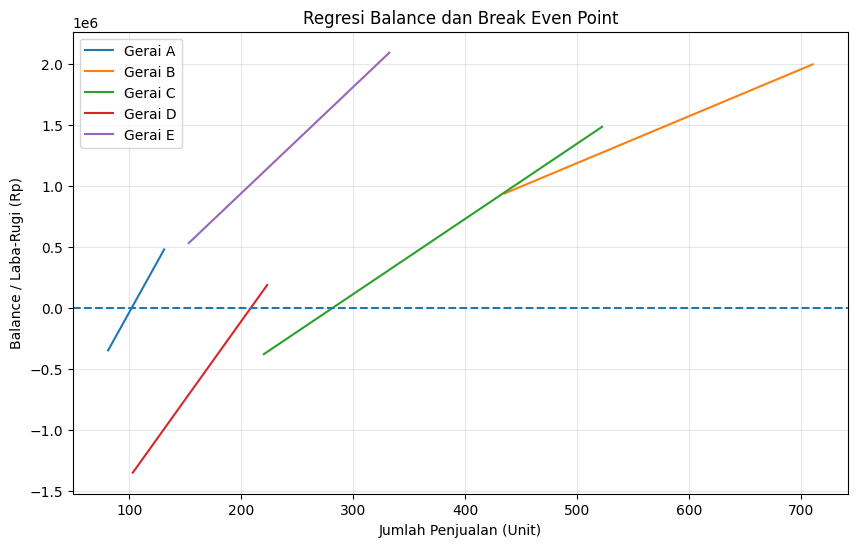

In [ ]:
plt.figure(figsize=(10, 6))

for gerai in df["Gerai"].unique():

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Balance (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    x_line = np.linspace(
        data["Jumlah Terjual (Unit)"].min(),
        data["Jumlah Terjual (Unit)"].max(),
        100
    ).reshape(-1, 1)

    y_line = model.predict(x_line)

    plt.plot(x_line, y_line, label=gerai)

# Garis BEP
plt.axhline(0, linestyle="--")

plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Balance / Laba-Rugi (Rp)")
plt.title("Regresi Balance dan Break Even Point")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Interpretasi singkat

Grafik menunjukkan hubungan antara jumlah penjualan dan Balance (laba-rugi) pada masing-masing gerai. Garis putus-putus pada Balance = 0 merupakan titik impas (BEP). Perpotongan garis regresi dengan garis tersebut menunjukkan perkiraan jumlah unit yang harus terjual agar gerai mencapai BEP. Semakin ke kanan titik perpotongannya, semakin banyak unit yang diperlukan untuk mencapai titik impas.

# KESIMPULAN

Hasil analisis menunjukkan bahwa terdapat hubungan linear antara jumlah penjualan dan revenue pada kelima gerai. Nilai R² sebesar 1 menunjukkan bahwa variasi revenue dalam dataset dapat dijelaskan sepenuhnya oleh jumlah unit yang terjual. Perbedaan kemiringan pada masing-masing garis regresi menunjukkan adanya perbedaan nilai revenue yang diperoleh dari setiap unit penjualan, yang berkaitan dengan perbedaan harga jual pada masing-masing gerai.

Selanjutnya, analisis Break Even Point (BEP) dilakukan menggunakan regresi antara jumlah penjualan dan balance. Titik BEP diperoleh dengan mencari nilai penjualan ketika balance berada pada angka nol, yaitu kondisi ketika pendapatan telah mampu menutupi biaya yang tercatat dalam dataset. Berdasarkan hasil perhitungan, BEP Gerai A sekitar 102 unit, Gerai B 191 unit, Gerai C 281 unit, Gerai D 208 unit, dan Gerai E 92 unit per hari. Dengan demikian, masing-masing gerai memiliki kebutuhan volume penjualan yang berbeda untuk mencapai titik impas sesuai dengan kondisi pendapatan dan biaya yang terdapat dalam dataset.
